In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_excel('/content/Travel_Hospitality_Dataset.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,Column1,CANCELLED,LEAD TIME,ARRIVAL DATE YEAR,ARRIVAL DATE MONTHS,STAYS IN WEEKEND NIGHTS,STAYS IN WEEK NIGHTS,ADULTS,CHILDREN,BABIES,COUNTRY,MARKET SEGEMENT,DISTRIBUTION CHANNEL,PREVIOUS CANCELLATION,RESERVED ROOM TYPE,BOOKING CHANGES,DEPOSITE TYPE,ADDRESS,CUSTOMER TYPE
0,City Hotel,1,105,2025,February,0,8,4,0,0,GBR,Corporate,Offline,5,C,3,Refundable,211.55,Group
1,City Hotel,0,146,2025,September,2,5,1,0,0,AUS,Groups,Offline,1,A,0,Refundable,131.88,Group
2,Resort Hotel,1,200,2025,March,1,7,2,0,0,USA,Groups,Offline,2,B,1,Refundable,86.34,Contract
3,City Hotel,0,218,2025,May,3,14,3,2,0,USA,Groups,Travel Agent,5,C,0,Refundable,148.74,Contract
4,City Hotel,0,79,2025,November,0,14,2,2,1,CAN,Corporate,Online,2,B,0,No Deposit,195.43,Transient


In [2]:
# Display information about the DataFrame to check data types and missing values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Column1                   22 non-null     object 
 1   CANCELLED                 22 non-null     int64  
 2   LEAD TIME                 22 non-null     int64  
 3   ARRIVAL DATE YEAR         22 non-null     int64  
 4   ARRIVAL DATE MONTHS       22 non-null     object 
 5   STAYS IN WEEKEND NIGHTS   22 non-null     int64  
 6   STAYS IN WEEK NIGHTS      22 non-null     int64  
 7   ADULTS                    22 non-null     int64  
 8   CHILDREN                  22 non-null     int64  
 9   BABIES                    22 non-null     int64  
 10  COUNTRY                   22 non-null     object 
 11  MARKET SEGEMENT           22 non-null     object 
 12  DISTRIBUTION CHANNEL      22 non-null     object 
 13  PREVIOUS CANCELLATION     22 non-null     int64  
 14  RESERVED ROO

None

['Column1', 'CANCELLED', 'LEAD TIME ', 'ARRIVAL DATE YEAR ', 'ARRIVAL DATE MONTHS ', 'STAYS IN WEEKEND NIGHTS ', 'STAYS IN WEEK NIGHTS ', 'ADULTS ', 'CHILDREN', 'BABIES ', 'COUNTRY', 'MARKET SEGEMENT ', 'DISTRIBUTION CHANNEL ', 'PREVIOUS CANCELLATION', 'RESERVED ROOM TYPE ', 'BOOKING CHANGES', 'DEPOSITE TYPE ', 'ADDRESS ', 'CUSTOMER TYPE ']


In [ ]:
print(df.columns.tolist())

### Distribution Plots for Booking Lead Time and ADR

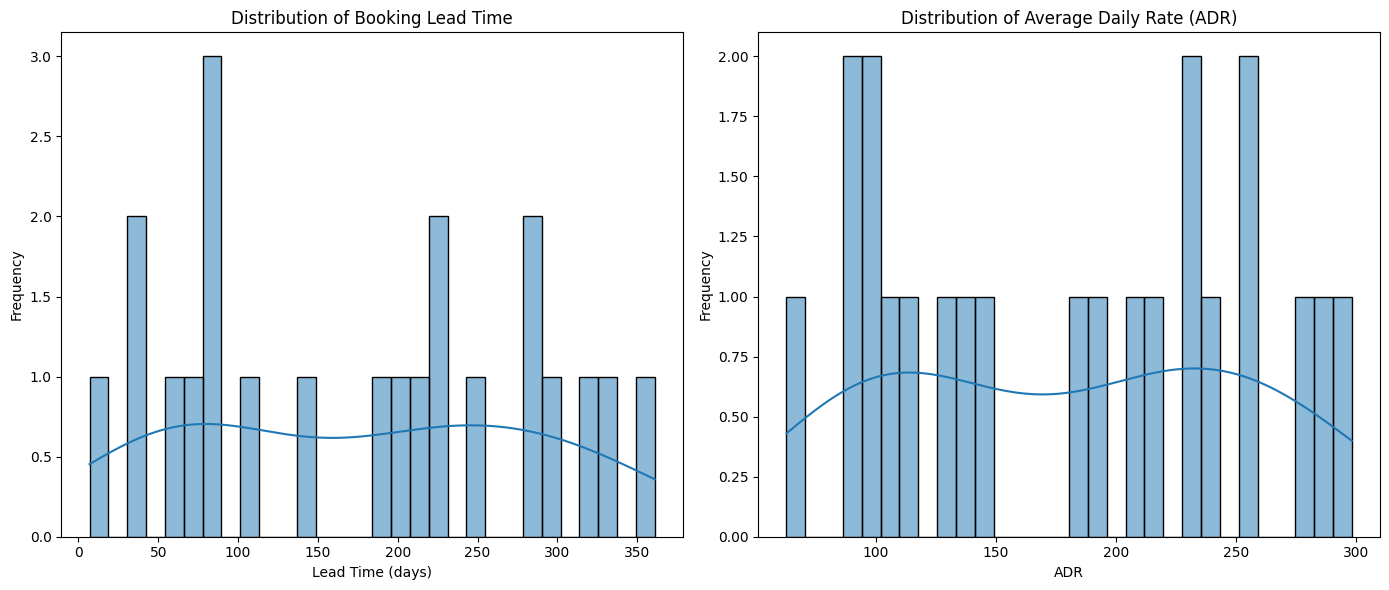

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['LEAD TIME '], kde=True, bins=30)
plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['ADDRESS '], kde=True, bins=30) # Assuming 'ADDRESS ' is ADR or a similar pricing column. If not, please specify the correct ADR column name
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Cancellation Box Plots to Detect Outliers in Pricing and Booking Behavior

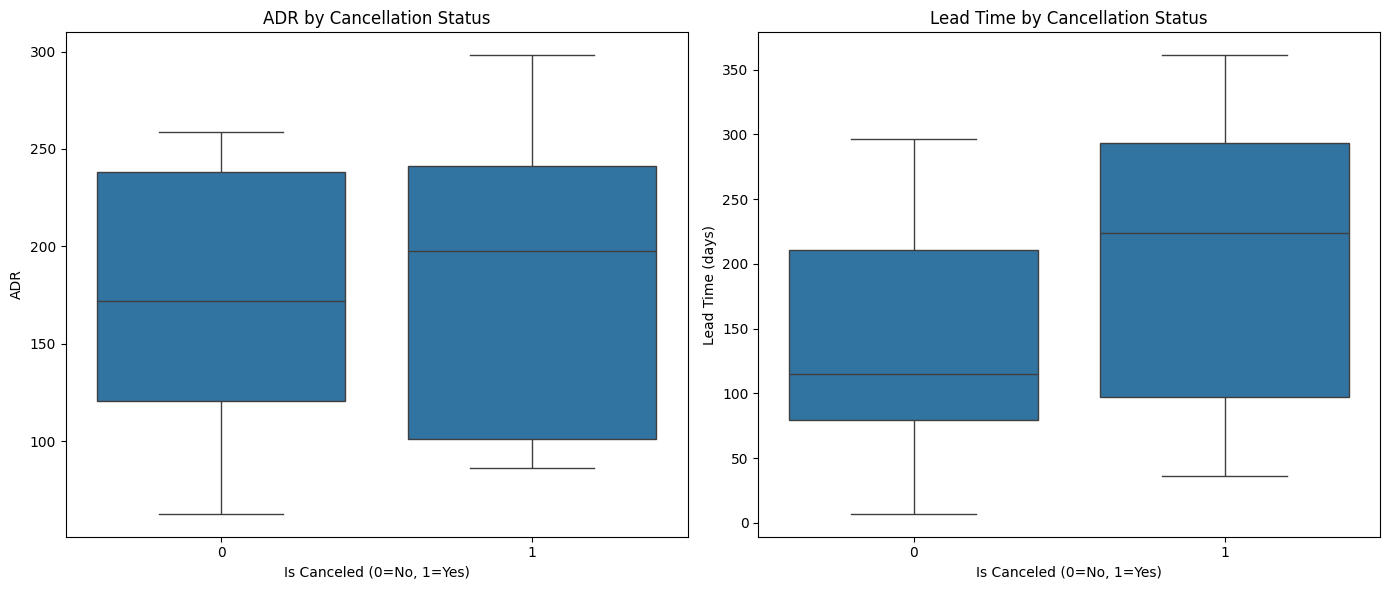

In [13]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='CANCELLED', y='ADDRESS ', data=df) # Assuming 'ADDRESS ' is ADR or a similar pricing column. If not, please specify the correct ADR column name
plt.title('ADR by Cancellation Status')
plt.xlabel('Is Canceled (0=No, 1=Yes)')
plt.ylabel('ADR')

plt.subplot(1, 2, 2)
sns.boxplot(x='CANCELLED', y='LEAD TIME ', data=df)
plt.title('Lead Time by Cancellation Status')
plt.xlabel('Is Canceled (0=No, 1=Yes)')
plt.ylabel('Lead Time (days)')

plt.tight_layout()
plt.show()

### Heatmaps to Visualize Correlation Between Variables

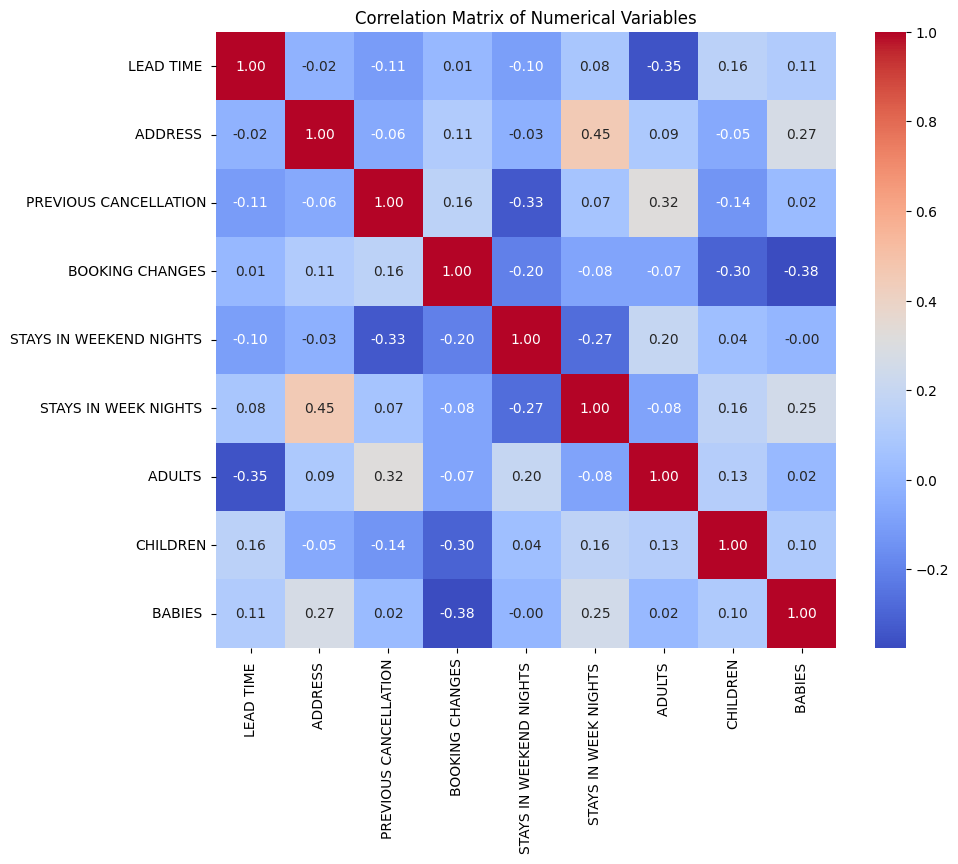

In [14]:
# Select relevant numerical columns for correlation analysis
numerical_cols = ['LEAD TIME ', 'ADDRESS ', 'PREVIOUS CANCELLATION', 'BOOKING CHANGES', 'STAYS IN WEEKEND NIGHTS ', 'STAYS IN WEEK NIGHTS ', 'ADULTS ', 'CHILDREN', 'BABIES ']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Unique Deposit Types: ['Refundable' 'No Deposit' 'Non Refund']
Unique Customer Types: ['Group' 'Contract' 'Transient']


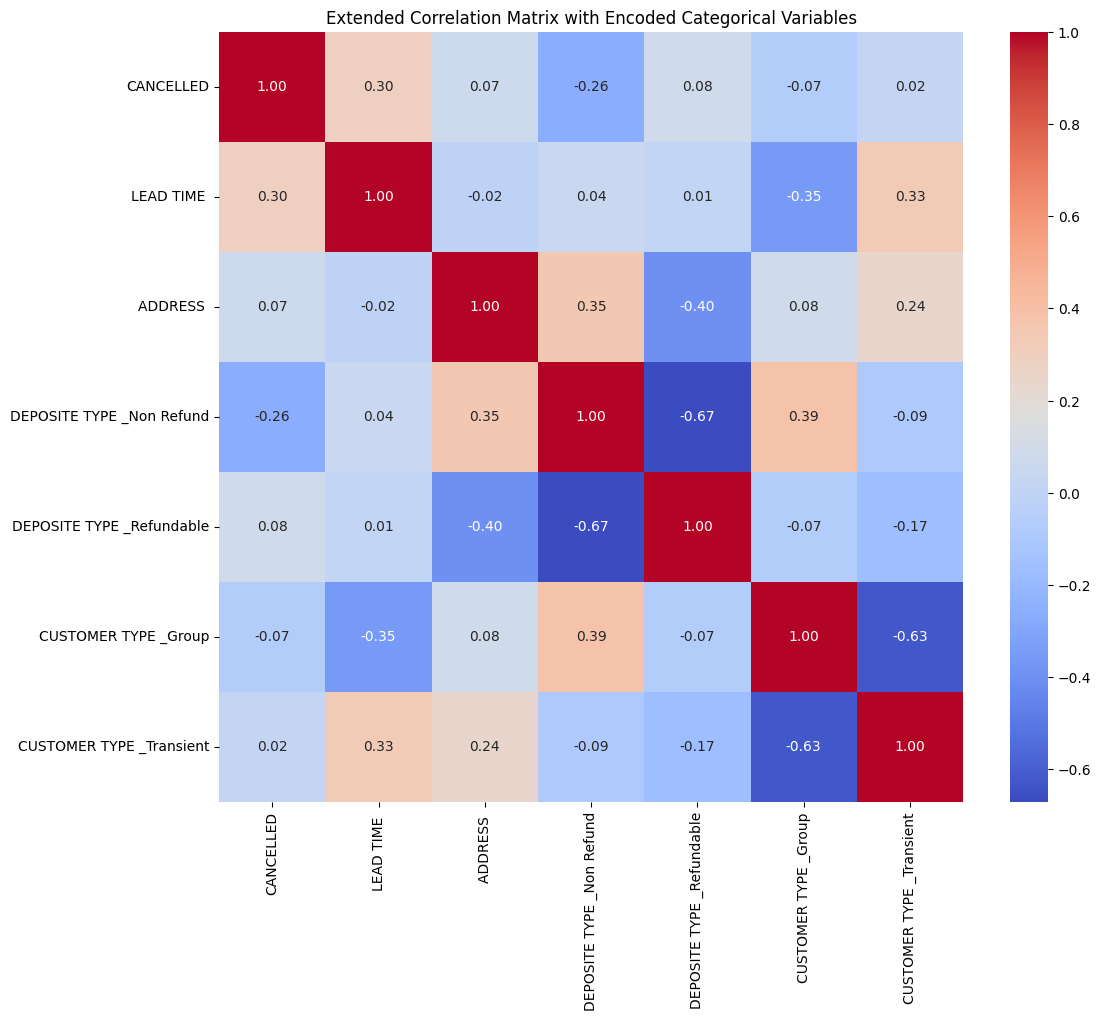

In [15]:
# For categorical variables like 'DEPOSITE TYPE ' and 'CUSTOMER TYPE ',
# we might need to convert them to numerical representations (e.g., using one-hot encoding)
# to include them in a correlation heatmap with numerical variables.
# Or, we can analyze their relationship with other variables using different visualization types.

# Let's consider a simplified correlation for 'DEPOSITE TYPE ' and 'CUSTOMER TYPE '
# by first checking their unique values and then attempting to encode them if they're not too many categories.

print("Unique Deposit Types:", df['DEPOSITE TYPE '].unique())
print("Unique Customer Types:", df['CUSTOMER TYPE '].unique())

# Assuming these are nominal categories, let's one-hot encode them to see some interaction
# with a target variable like 'CANCELLED' or 'ADDRESS '.

# Example: Correlation with 'CANCELLED' for encoded categorical features
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, columns=['DEPOSITE TYPE ', 'CUSTOMER TYPE '], drop_first=True)

# Select numerical and newly encoded columns
relevant_cols = ['CANCELLED', 'LEAD TIME ', 'ADDRESS '] + [col for col in df_encoded.columns if 'DEPOSITE TYPE _' in col or 'CUSTOMER TYPE _' in col] # Adjusted filter for dummy column names with spaces
correlation_matrix_extended = df_encoded[relevant_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_extended, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Extended Correlation Matrix with Encoded Categorical Variables')
plt.show()

### Scatter Plot: Lead Time vs. ADR (Address)

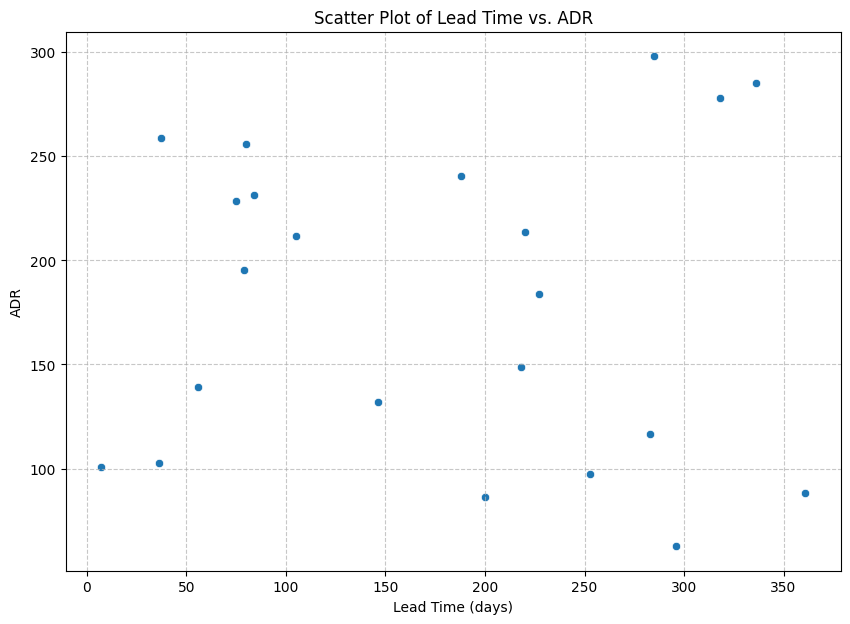

In [16]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='LEAD TIME ', y='ADDRESS ', data=df)
plt.title('Scatter Plot of Lead Time vs. ADR')
plt.xlabel('Lead Time (days)')
plt.ylabel('ADR')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()